<a href="https://colab.research.google.com/github/jfodera/College-Exam-Hub/blob/main/03_HF_Pipelines_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2

The environment setup recommended by the notes was used

In [1]:
pip install -U transformers datasets evaluate accelerate torch torchvision pillow

In [2]:
from transformers import pipeline

## Part A

Image classification

In [3]:
import requests
from PIL import Image

img_clf = pipeline('image-classification', model='google/vit-base-patch16-224')

## Example
img_url = "https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png"
image = Image.open(requests.get(img_url, stream=True).raw)

classification_results = img_clf(image)

# The pipeline returns a list of dictionaries containing labels and confidence scores
for idx, result in enumerate(classification_results):
    print(f"{idx + 1}. Label: {result['label']}, Confidence: {result['score']:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

1. Label: macaw, Confidence: 0.9905
2. Label: African grey, African gray, Psittacus erithacus, Confidence: 0.0056
3. Label: toucan, Confidence: 0.0011
4. Label: sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita, Confidence: 0.0007
5. Label: lorikeet, Confidence: 0.0007


Object Detection

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

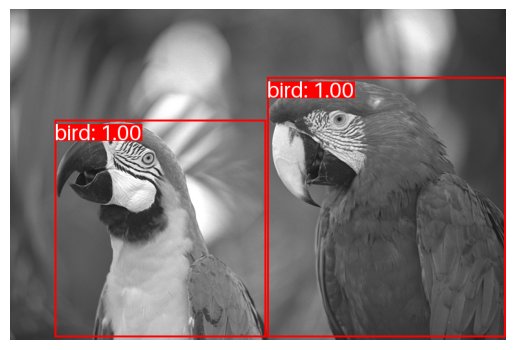

In [4]:
det = pipeline('object-detection', model='facebook/detr-resnet-50')
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

## Example
img_url = "https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png"
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

pred = det(image)

draw = ImageDraw.Draw(image)

font = ImageFont.load_default(size=32)

for p in pred:
    box = p['box']
    label = p['label']
    score = p['score']

    xmin, ymin, xmax, ymax = box.values()

    draw.rectangle([(xmin, ymin), (xmax, ymax)], outline="red", width=3)

    text = f"{label}: {score:.2f}"

    # Draw background rectangle for readability
    text_bbox = draw.textbbox((xmin, ymin), text, font=font)
    draw.rectangle(text_bbox, fill="red")

    # Draw text
    draw.text((xmin, ymin), text, fill="white", font=font)

# Display image
plt.imshow(image)
plt.axis("off")
plt.show()


## Part B

In [5]:
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset("cifar10", split="train[:20]")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

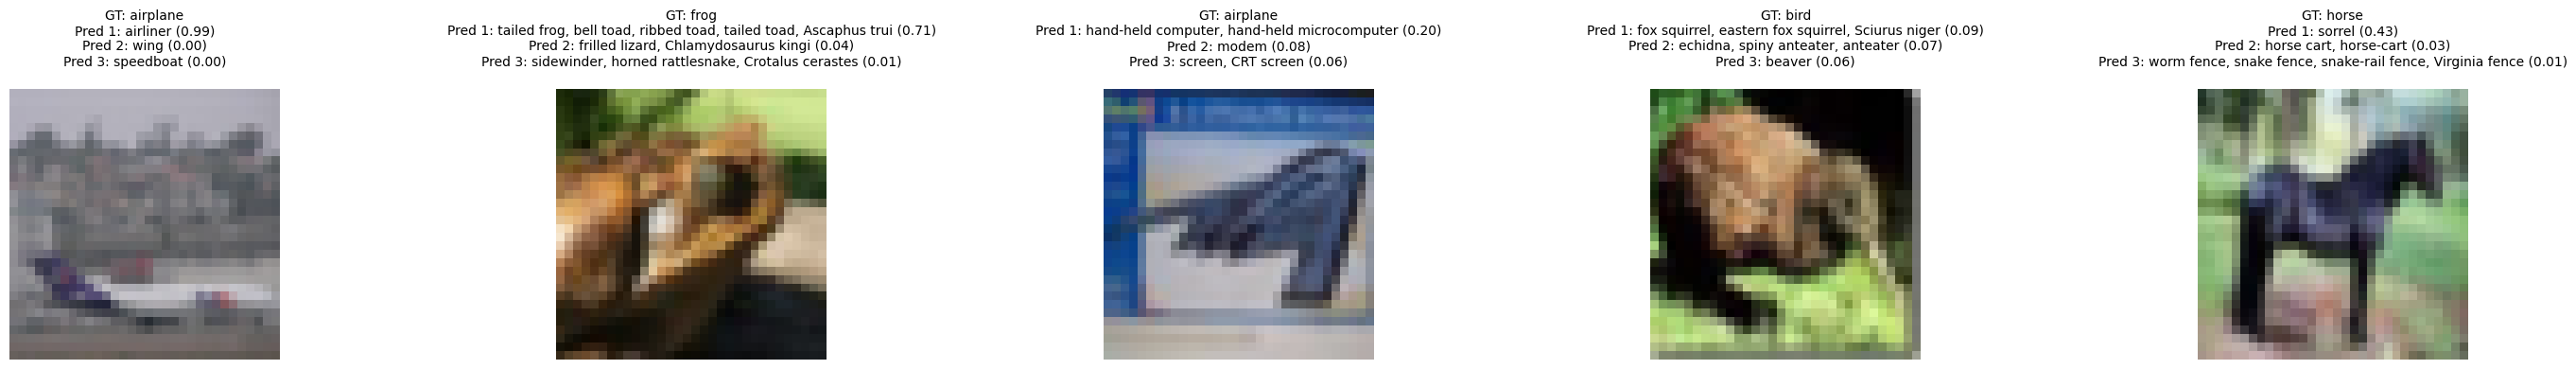

In [6]:
label_names = dataset.features["label"].names
num_images_to_display = 5
fig, axes = plt.subplots(1, num_images_to_display, figsize=(30, 4))

for i in range(num_images_to_display):
    sample = dataset[i]
    image = sample['img']
    gt_label = label_names[sample['label']]

    vit_clf_predictions = img_clf(image)

    # Display the image
    axes[i].imshow(image)
    axes[i].axis('off')

    # Prepare title with ground truth and top predictions
    title_text = f"GT: {gt_label}\n"
    for j, pred in enumerate(vit_clf_predictions[:3]): # Display top 3 predictions
        title_text += f"Pred {j+1}: {pred['label']} ({pred['score']:.2f})\n"
    axes[i].set_title(title_text, fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
dataset = load_dataset("detection-datasets/coco", split="val")

# Create small subset (20 images)
images = [dataset[i]["image"].convert("RGB") for i in range(20)]

README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00040-67e35002d15215(…):   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00001-of-00040-2c2b33b9504aa8(…):   0%|          | 0.00/489M [00:00<?, ?B/s]

...

data/train-00039-of-00040-f1a97fa690638b(…):   0%|          | 0.00/474M [00:00<?, ?B/s]

data/val-00000-of-00002-c4f2e391ee4aba11(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

data/val-00001-of-00002-7af5414a3b178949(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117266 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4952 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


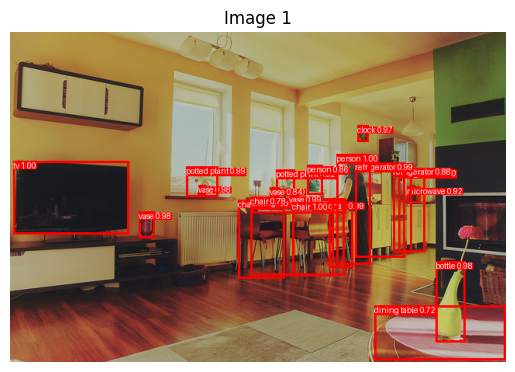

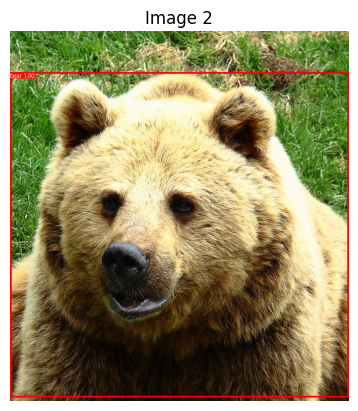

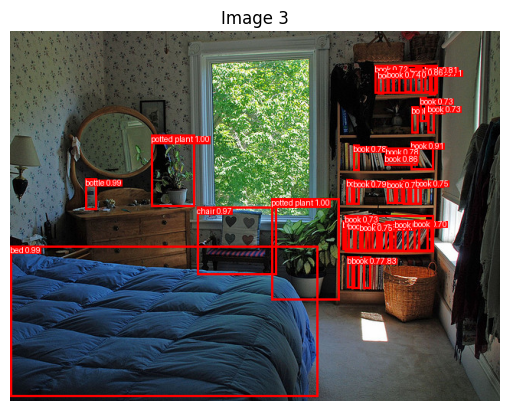

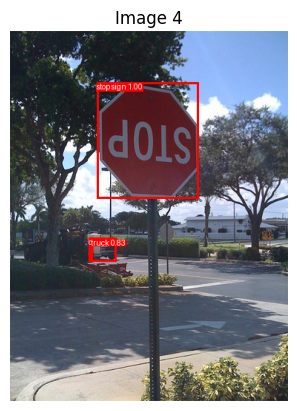

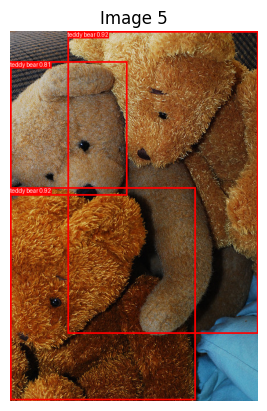

In [8]:
# Load Object detection model
det = pipeline('object-detection', model='facebook/detr-resnet-50')

font = ImageFont.load_default()

# Run + display first 5 images
for i in range(5):
    img = images[i].copy()
    draw = ImageDraw.Draw(img)

    preds = det(img)

    for p in preds:
        if p['score'] < 0.7:
            continue

        xmin, ymin, xmax, ymax = p['box'].values()
        label = f"{p['label']} {p['score']:.2f}"

        # Draw box
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)

        # Draw label background
        text_bbox = draw.textbbox((xmin, ymin), label, font=font)
        draw.rectangle(text_bbox, fill="red")

        # Draw text
        draw.text((xmin, ymin), label, fill="white", font=font)

    # Show image
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")
    plt.show()

## Part C

In [9]:
import time
from transformers import pipeline
from datasets import load_dataset

print("Loading CIFAR-10 dataset...")
ds = load_dataset("cifar10", split="train[:100]")

num_images = len(ds)
print(f"Running evaluation on {num_images} images from CIFAR-10\n")

cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

true_labels = [cifar_class_names[ds[i]['label']] for i in range(num_images)]

print("Loading ViT-Base model...")
vit_clf = pipeline('image-classification', model='google/vit-base-patch16-224')

vit_latencies = []
vit_predictions = []

print("Running ViT-Base...")
start_total = time.time()

for i in range(num_images):
    img = ds[i]['img']

    start = time.time()
    results = vit_clf(img)
    latency = time.time() - start

    pred_label = results[0]['label']

    vit_latencies.append(latency)
    vit_predictions.append(pred_label)

    if (i + 1) % 25 == 0 or i == num_images - 1:
        print(f"  ViT processed {i+1}/{num_images} images...")

vit_avg_latency = sum(vit_latencies) / num_images
vit_total_time = time.time() - start_total

vit_correct = sum(1 for pred, true in zip(vit_predictions, true_labels)
                  if true.lower() in pred.lower() or pred.lower() in true.lower())
vit_accuracy = (vit_correct / num_images) * 100

print(f"\nViT-Base completed!")
print(f"Avg latency: {vit_avg_latency:.4f} s/image | Total time: {vit_total_time:.2f} s")
print(f"Accuracy: {vit_accuracy:.1f}%\n")

print("Loading ResNet-50 model...")
resnet_clf = pipeline('image-classification', model='microsoft/resnet-50')

resnet_latencies = []
resnet_predictions = []

print("Running ResNet-50...")
start_total = time.time()

for i in range(num_images):
    img = ds[i]['img']

    start = time.time()
    results = resnet_clf(img)
    latency = time.time() - start

    pred_label = results[0]['label']

    resnet_latencies.append(latency)
    resnet_predictions.append(pred_label)

    if (i + 1) % 25 == 0 or i == num_images - 1:
        print(f"  ResNet processed {i+1}/{num_images} images...")

resnet_avg_latency = sum(resnet_latencies) / num_images
resnet_total_time = time.time() - start_total

resnet_correct = sum(1 for pred, true in zip(resnet_predictions, true_labels)
                     if true.lower() in pred.lower() or pred.lower() in true.lower())
resnet_accuracy = (resnet_correct / num_images) * 100

print(f"\nResNet-50 completed!")
print(f"Avg latency: {resnet_avg_latency:.4f} s/image | Total time: {resnet_total_time:.2f} s")
print(f"Accuracy: {resnet_accuracy:.1f}%\n")

print("\n" + "="*95)
print("MODEL COMPARISON ON CIFAR-10 (first 100 images)")
print("="*95)
print(f"{'Model':<32} {'Avg Latency (s)':<18} {'Total Time (s)':<16} {'Accuracy (%)':<14} {'Example Top-1 Prediction':<35}")
print("-"*110)
print(f"{'google/vit-base-patch16-224':<32} {vit_avg_latency:<18.4f} {vit_total_time:<16.2f} {vit_accuracy:<14.1f} {vit_predictions[0]:<35}")
print(f"{'microsoft/resnet-50':<32} {resnet_avg_latency:<18.4f} {resnet_total_time:<16.2f} {resnet_accuracy:<14.1f} {resnet_predictions[0]:<35}")
print("="*110)

# Save results to file
with open("model_comparison_cifar100_with_accuracy.txt", "w") as f:
    f.write("Image Classification Model Comparison - CIFAR-10 (first 100 images)\n\n")
    f.write(f"ViT-Base    → Avg latency: {vit_avg_latency:.4f}s | Total: {vit_total_time:.2f}s | Accuracy: {vit_accuracy:.1f}%\n")
    f.write(f"ResNet-50   → Avg latency: {resnet_avg_latency:.4f}s | Total: {resnet_total_time:.2f}s | Accuracy: {resnet_accuracy:.1f}%\n\n")
    f.write("First image results:\n")
    f.write(f"ViT:    {vit_predictions[0]} ({vit_accuracy:.1f}% overall)\n")
    f.write(f"ResNet: {resnet_predictions[0]} ({resnet_accuracy:.1f}% overall)\n")

Loading CIFAR-10 dataset...
Running evaluation on 100 images from CIFAR-10

Loading ViT-Base model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Running ViT-Base...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  ViT processed 25/100 images...
  ViT processed 50/100 images...
  ViT processed 75/100 images...
  ViT processed 100/100 images...

ViT-Base completed!
Avg latency: 0.0173 s/image | Total time: 1.76 s
Accuracy: 18.0%

Loading ResNet-50 model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Running ResNet-50...
  ResNet processed 25/100 images...
  ResNet processed 50/100 images...
  ResNet processed 75/100 images...
  ResNet processed 100/100 images...

ResNet-50 completed!
Avg latency: 0.0155 s/image | Total time: 1.59 s
Accuracy: 6.0%


MODEL COMPARISON ON CIFAR-10 (first 100 images)
Model                            Avg Latency (s)    Total Time (s)   Accuracy (%)   Example Top-1 Prediction           
--------------------------------------------------------------------------------------------------------------
google/vit-base-patch16-224      0.0173             1.76             18.0           airliner                           
microsoft/resnet-50              0.0155             1.59             6.0            airliner                           


Vit uses a vision transformer architecture which allows it to capture more global information and long range information across the image. Additionally it is trained on 14 million images so it has a wider range. The transformer architecture makes it slower.

Compared to Resnet50 which uses a CNN architecture which is more specific to local patterns in images and captures less the global patterns like a transformer. It is trained on ImageNet-1k which is smaller and has fewer classes than Vit

